# Simulator

In [19]:
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt

## Definition of System Parameters

### Cost Parameters

In [20]:
cost_failure = 1200
cost_component = 100
cost_inspection = 100
cost_replacement = 1000

### Model Parameters

Define the parameters $\eta = 30*24 h$, one month, $\beta = 3$ for the components "Fail Age" given by a Weibull distribution.

Define the expiration age as $110\%$ of $\mu$ for the automatic mandatory component replacement, despite inspections. 

In [21]:
eta = 30*24
beta = 3

expiration = 1.1*eta

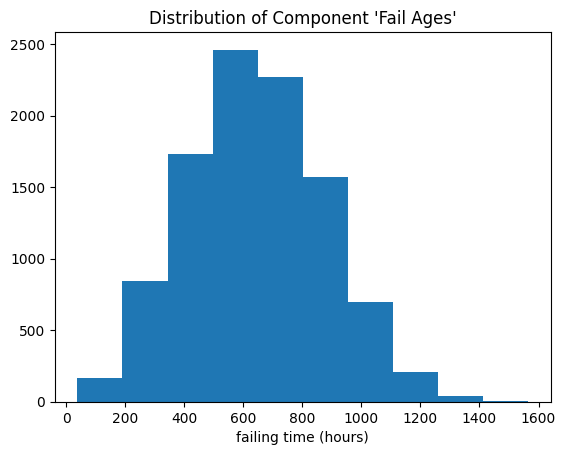

In [22]:
fail_ages = eta*np.random.weibull(beta, size=10000)

plt.hist(fail_ages)
plt.xlabel("failing time (hours)")
plt.title("Distribution of Component 'Fail Ages'")
plt.show()

### Inspection Schedule Parameters

Define the parameters $\mu = 7*24 h$, one week, $\sigma = 15\%$ of $ \mu$ for the time between inspections, given by a Normal distribution.

Also, when an inspection is required but not urgent, the time for said inspectin is scheduled following an Exponential distribution of parameter $\theta = 12h$

In [23]:
mu = 7*24
sigma = 0.15*mu

theta = 12

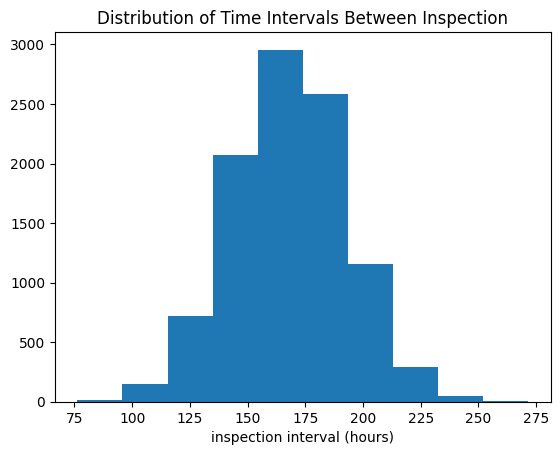

In [24]:
inspection_windows = np.random.normal(loc=mu, scale=sigma, size=10000)

plt.hist(inspection_windows)
plt.xlabel("inspection interval (hours)")
plt.title("Distribution of Time Intervals Between Inspection")
plt.show()

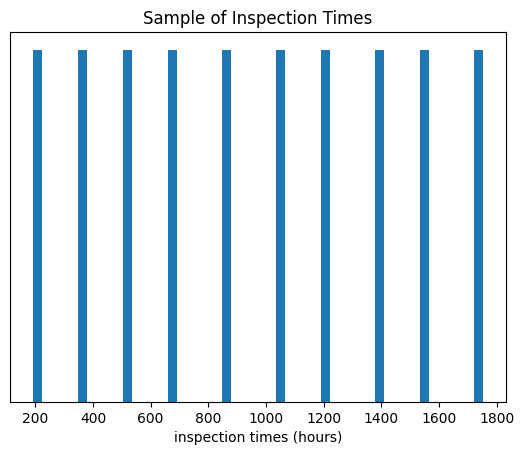

In [25]:
inspection_times = np.cumsum(inspection_windows)[:10]

plt.hist(inspection_times, bins=50)
plt.xlabel("inspection times (hours)")
plt.yticks([])
plt.title("Sample of Inspection Times")
plt.show()

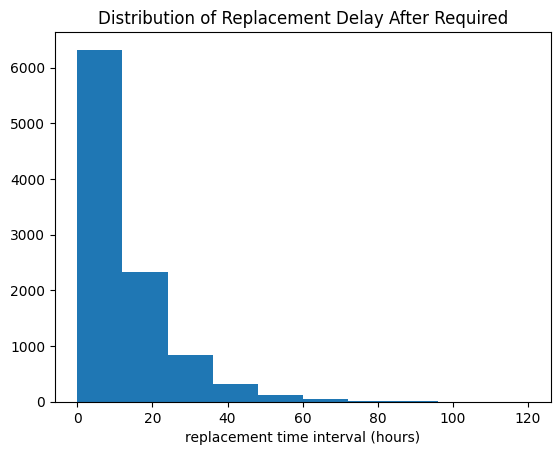

In [26]:
inspection_windows = np.random.exponential(theta, size=10000)

plt.hist(inspection_windows)
plt.xlabel("replacement time interval (hours)")
plt.title("Distribution of Replacement Delay After Required")
plt.show()

### Inspection Quality Parameters

The objective of an inspection is to check if a component is old, that can be seen as presenting wearing signals. Since the age of a component is known, but not exactly its distribution, we model this fenomenon as follows:
 * A measure of the age/wear of a component will be an estimation the CDF (Cumulated Density Function) if its fail age; if the pdf is close the 0 the component is new, and if it is close to 1, it almost centainly will present a pane
 * Since the inspection is not perfect, we consider a distribution around the exact CDF in question; this is done by considering a Beta distribution whose average is the exact CDF, $Mean = CDF(component)$ and variance given by $Var = \alpha* Mean*(1-Mean)$, where $0 < \alpha < 1$ is a quality measure, this is due to a known constraint that in a Beta distribution the variance is required to be inferior to $Mean*(1-Mean)$.
 * The parameters $a,b$ of the Beta distribution are finally given as follows, based on: $a =  CDF* (CDF*(1-CDF)/VAR-1)$ and $b = (1-CDF)*(CDF*(1-CDF)/VAR-1)$. See https://en.wikipedia.org/wiki/Beta_distribution#Mean_and_variance for clarification

In [27]:
inspection_threshold = 0.5
inspection_deviation = 0.05

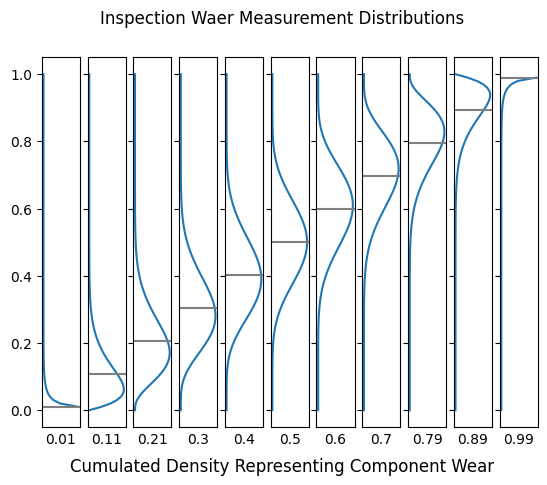

In [28]:
n = 11
fig, ax = plt.subplots(1, n, sharey=True)

cdfs = np.linspace(0.01,0.99,n)

sample = np.linspace(0,1,100)
for i in range(n):
    age_cdf = cdfs[i]

    var = inspection_deviation*age_cdf*(1-age_cdf)
    a = age_cdf * (age_cdf*(1-age_cdf)/var-1)
    b = (1-age_cdf)*(age_cdf*(1-age_cdf)/var-1)
    
    pdf = scp.stats.beta.pdf(sample, a, b)

    ax[i].plot(pdf, sample)
    ax[i].axhline(y=age_cdf, color="gray")
    ax[i].set_xlabel(age_cdf.round(2))
    ax[i].set_xticks([])

plt.suptitle("Inspection Waer Measurement Distributions")
fig.supxlabel("Cumulated Density Representing Component Wear")
plt.show()

### Simulate

We show an example of how to use the simulator implemented in the package `simmcm2d` to obtain samples. Do not forget to have the library in question installed in order to run the following.

In [29]:
from simmcm2d import sample_datasets, sample_datasets_conf

In [30]:
param = {
    "eta":eta,
    "beta":beta,
    "expiration":expiration,

    "mu":mu,
    "sigma":sigma,
    "theta":theta,
    "inspection_deviation":inspection_deviation,
    "inspection_threshold":inspection_threshold,
}

costs = {
    "replacement":cost_replacement,
    "inspection":cost_inspection,
    "component":cost_component,
    "failure":cost_failure
}

conf = {
    "param":param,
    "costs":costs,
    "n_systems":10,
    "n_events":10000,
    "time_origin":0,
    "id_0_component":0,
    "id_0_system":0
}

In [31]:
# df = sample_datasets(**conf)
df = sample_datasets(param, costs, n_systems = 10, n_events = 10000,
                     time_origin=0, id_0_component=0, id_0_system=0)

df.head()

,system_id,component_id,event_date,event_time,event_type,event_report,system_age,component_age,usage_since_last_event_h,FF,cost_event,cost_cumulated
0,4,4,1970-01-06,23:24:36,inspection,NaN,143.41,143.41,143.41,None,100,100
1,8,8,1970-01-07,02:01:52,inspection,NaN,146.03,146.03,146.03,None,100,100
2,9,9,1970-01-07,16:26:24,inspection,NaN,160.44,160.44,160.44,None,100,100
3,5,5,1970-01-07,20:00:01,inspection,NaN,164.00,164.00,164.00,None,100,100
4,1,1,1970-01-07,20:03:57,inspection,NaN,164.07,164.07,164.07,None,100,100


### Using Json Configuration

Alternative to the previous direct call, one can take advantage of using a `.json` configuration file as follows, by reading the configuration file and passng directly the parameters, or by using the specific function:

In [32]:
conf_filepath = "sample_system_dataset.json"

df = sample_datasets_conf(conf_filepath)
df.head()

,system_id,component_id,event_date,event_time,event_type,event_report,system_age,component_age,usage_since_last_event_h,FF,cost_event,cost_cumulated
0,10,10,1970-01-05,17:03:33,inspection,NaN,113.06,113.06,113.06,None,100,100
1,9,9,1970-01-06,03:34:41,inspection,NaN,123.58,123.58,123.58,None,100,100
2,2,2,1970-01-07,01:46:35,inspection,NaN,145.78,145.78,145.78,None,100,100
3,8,8,1970-01-08,01:42:07,inspection,NaN,169.70,169.70,169.70,None,100,100
4,3,3,1970-01-08,02:23:45,inspection,NaN,170.40,170.40,170.40,None,100,100


### Saving to Outputs Files

If the parameters implement the fields:
 * `output_data_filepath` - used to save the dataframe generated
 * `output_table_filepath` - used to save/reunite the parameters used
 
the speficied filepath are used to save the relevant data:

In [33]:
conf["output_data_filepath"] = "sample_system_dataset_1.csv"
conf["output_table_filepath"] = "sample_system_datatable.csv"

In [34]:
df = sample_datasets(**conf)
df.head()

,system_id,component_id,event_date,event_time,event_type,event_report,system_age,component_age,usage_since_last_event_h,FF,cost_event,cost_cumulated
0,2,2,1970-01-06,05:37:22,inspection,NaN,125.62,125.62,125.62,None,100,100
1,3,3,1970-01-06,12:49:35,inspection,NaN,132.83,132.83,132.83,None,100,100
2,8,8,1970-01-06,22:43:37,inspection,NaN,142.73,142.73,142.73,None,100,100
3,5,5,1970-01-07,04:28:22,inspection,NaN,148.47,148.47,148.47,None,100,100
4,6,6,1970-01-07,06:10:21,inspection,NaN,150.17,150.17,150.17,None,100,100


### Observe the distribution of fail ages

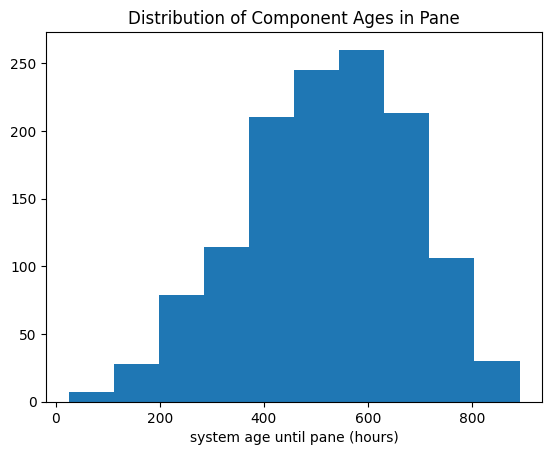

In [35]:
plt.hist(df[df.event_type=="failure"].component_age)
plt.xlabel("system age until pane (hours)")
plt.title("Distribution of Component Ages in Pane")
plt.show()

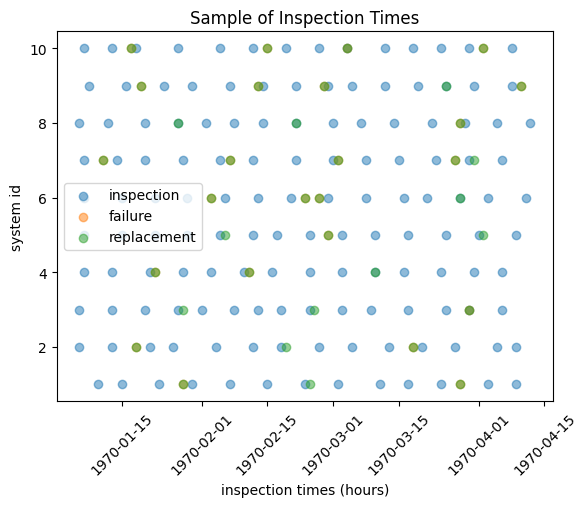

In [36]:
n_events_show = 200
for e_type in df.event_type.unique():
    df_ = df[:n_events_show]
    df_ = df_[df_.event_type == e_type]
    plt.scatter(df_.event_date,
                df_.system_id,
                label=e_type,
                alpha=0.5)

plt.legend()
plt.xlabel("inspection times (hours)")
plt.ylabel("system id")
plt.xticks(rotation=45)
plt.title("Sample of Inspection Times")
plt.show()